In [6]:
import healpy as hp
from scripts.utils import plot_cl_alm, load_data
from scripts.config import SimConfig

import matplotlib.pyplot as plt
from pixell import enmap, lensing, curvedsky, reproject
import numpy as np

# from scripts.utils import get_radii
from ksw import Cosmology, Data
import camb
from ksw.radial_functional import radial_func
from tqdm.auto import tqdm

from scipy.interpolate import CubicSpline
from joblib import Parallel, delayed

import os
import h5py
import seaborn as sns

In [7]:
def print_dir(dir_path, ext='.hdf5', print_keys=[], plot_keys=[], plot_sigmas=True):
    # Get a list of all files in the directory
    files = os.listdir(dir_path)
    # Filter the list to include only HDF5 files
    hdf5_files = [file for file in files if file.endswith(ext)]

    colors = sns.color_palette()

    to_plot = plot_keys != []

    if to_plot:
        fig, axs = plt.subplots(len(plot_keys), figsize=(10, 5*len(plot_keys)))
        axs = np.atleast_1d(axs)

        min_val = np.inf
        max_val = -np.inf
        for hdf5_file in hdf5_files:
            with h5py.File(os.path.join(dir_path, hdf5_file), 'r') as f:
                for key in plot_keys:
                    data = np.array(f[key])
                    min_val = min(min_val, data.min())
                    max_val = max(max_val, data.max())

    for j, hdf5_file in enumerate(hdf5_files):
        # Open the file
        with h5py.File(os.path.join(dir_path, hdf5_file), 'r') as f:
            # Print the file name
            print('File:', hdf5_file, 'Keys:', list(f.keys()))
            for key in print_keys:
                print('\t\t\t', key, ':', np.array(f[key]))

            if to_plot:
                for i, key in enumerate(plot_keys):
                    axs[i].set_title(key)

                    data = np.array(f[key])
                    min_val = min(min_val, data.min())
                    max_val = max(max_val, data.max())

                    if key == 'fnls':
                        data = data.reshape(-1)
                        sns.kdeplot(data, ax=axs[i], label=hdf5_file)
                        axs[i].set_xlabel(r'$f_{nl}^{true}$')
                    else:
                        sns.histplot(
                            data, ax=axs[i], kde=True, label=hdf5_file, stat="density")
                        axs[i].set_title(key)

                        if key == 'estimates':
                            axs[i].set_xlabel(r'$f_{nl}^{pred}$')

                        if key == 'errors':
                            axs[i].set_xlabel(
                                r'($f_{nl}^{pred}-f_{nl}^{true})/var$')

                            if plot_sigmas:
                                fisher = np.array(f['fisher'])
                                mean = 0  # by design
                                fisher_inv = 1/fisher  # np.linalg.inv(fisher)
                                std_dev = np.sqrt(np.diag(fisher_inv))

                                for sigma in range(1, 2):
                                    color = colors[j]
                                    axs[i].axvline(
                                        mean - sigma*std_dev, color=color, linestyle='dashed', linewidth=1)
                                    axs[i].axvline(
                                        mean + sigma*std_dev, color=color, linestyle='dashed', linewidth=1)
                    axs[i].set_xlim(min_val, max_val)
                    axs[i].set_xscale('symlog', linthresh=1)
                    
    if to_plot:
        for ax in axs:
            ax.legend()
        # plt.xlabel(r'$(f_{nl}^{pred,ksw}-f_{nl}^{true})/var$')
        fig.suptitle(f'Data loaded from: {dir_path}')
        plt.tight_layout()
        plt.show()

In [8]:
import os
import h5py

# Directory containing the HDF5 files
dir_path = "data/alm_cache"
print_dir(dir_path)

File: 512_nn_T_100_5.alms.hdf5 Keys: ['alm', 'almng']
File: 512_nn_T_100_2.alms.hdf5 Keys: ['alm', 'almng']
File: 512_nn_T_100_8.alms.hdf5 Keys: ['alm', 'almng']
File: 128_nn_T_100.alms.hdf5 Keys: ['alm', 'almng', 'settings']
File: 128_T_100.alms.hdf5 Keys: ['alm', 'almng', 'settings']
File: 2048_T_100.alms.hdf5 Keys: ['alm', 'settings']
File: 512_nn_T_100_1.alms.hdf5 Keys: ['alm', 'almng', 'settings']
File: 1024_nn_T_100.alms.hdf5 Keys: ['alm', 'settings']
File: 512_T_100.alms.hdf5 Keys: ['alm', 'almng', 'settings']
File: 512_nn_T_100_3.alms.hdf5 Keys: ['alm', 'almng']
File: 512_nn_T_100_4.alms.hdf5 Keys: ['alm', 'almng']
File: 256_T_100.alms.hdf5 Keys: ['alm', 'almng', 'settings']
File: 2048_nn_T_100.alms.hdf5 Keys: ['alm', 'settings']
File: 1024_T_100.alms.hdf5 Keys: ['alm', 'settings']
File: 512_nn_T_100.alms.hdf5 Keys: ['alm', 'almng', 'settings']
File: 512_nn_T_100_6.alms.hdf5 Keys: ['alm', 'almng']
File: 512_nn_T_100_10.alms.hdf5 Keys: ['alm', 'almng']
File: 512_nn_T_100_7.alms.

File: 128_T_100x10x10_fnl-1000-1000.hdf5 Keys: ['errors', 'errors_var', 'estimates', 'fisher', 'fisher_iso', 'fnls', 'patches', 'settings']
			 errors_var : [6.43061151e+11]
			 fisher : [0.00369262]
			 fisher_iso : [0.00366866]
File: 256_nn_T_100x10x10_fnl-1000-1000.hdf5 Keys: ['errors', 'errors_var', 'estimates', 'fisher', 'fisher_iso', 'fnls', 'patches', 'settings']
			 errors_var : [3.26270069e+09]
			 fisher : [0.73286327]
			 fisher_iso : [0.00840559]
File: 128_nn_T_100x10x10_fnl-1000-1000.hdf5 Keys: ['errors', 'errors_var', 'estimates', 'fisher', 'fisher_iso', 'fnls', 'patches', 'settings']
			 errors_var : [6.83689185e+09]
			 fisher : [0.32571699]
			 fisher_iso : [0.00366866]
File: 256_T_100x10x10_fnl-1000-1000.hdf5 Keys: ['errors', 'errors_var', 'estimates', 'fisher', 'fisher_iso', 'fnls', 'patches', 'settings']
			 errors_var : [2.68269062e+11]
			 fisher : [0.00846993]
			 fisher_iso : [0.00840556]


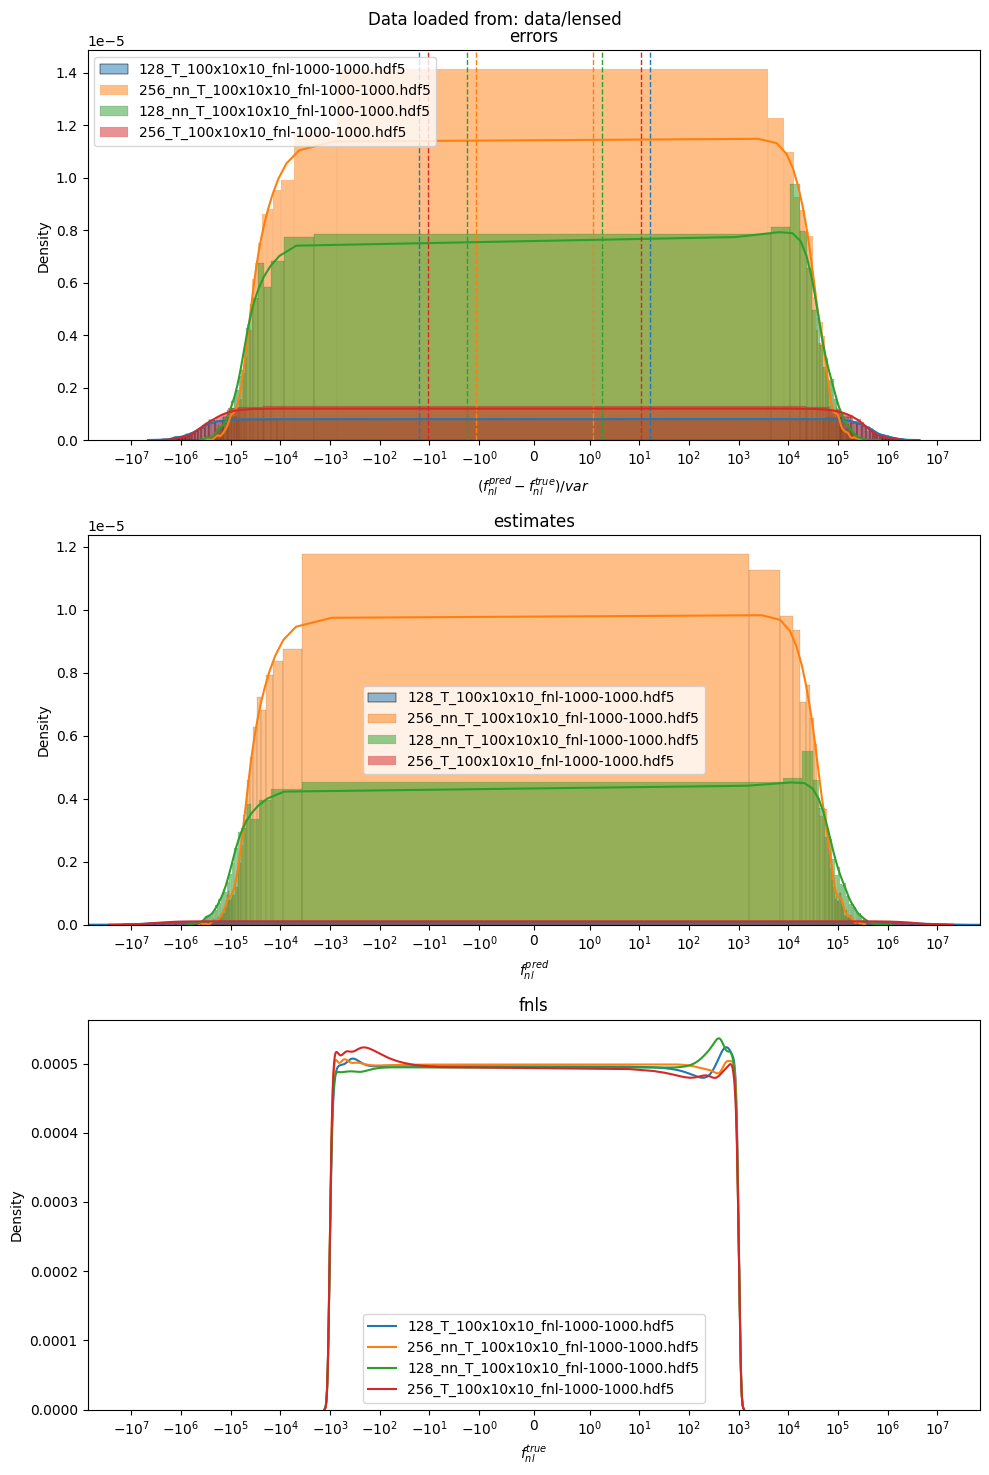

In [9]:
dir_path = 'data/lensed'
print_dir(dir_path, print_keys=['errors_var', 'fisher', 'fisher_iso'], plot_keys=[
          'errors', 'estimates', 'fnls'])

File: 256_nn_T_100x10x10_fnl-1000-1000.hdf5 Keys: ['errors', 'errors_var', 'estimates', 'fisher', 'fisher_iso', 'fnls', 'patches', 'settings']
			 errors_var : [3.24198201e+09]
			 fisher : [0.74476673]
			 fisher_iso : [0.00840559]


File: 128_nn_T_100x10x10_fnl-10-10.hdf5 Keys: ['errors', 'errors_var', 'estimates', 'fisher', 'fisher_iso', 'fnls', 'patches', 'settings']
			 errors_var : [6.88022516e+09]
			 fisher : [0.32121583]
			 fisher_iso : [0.00366866]


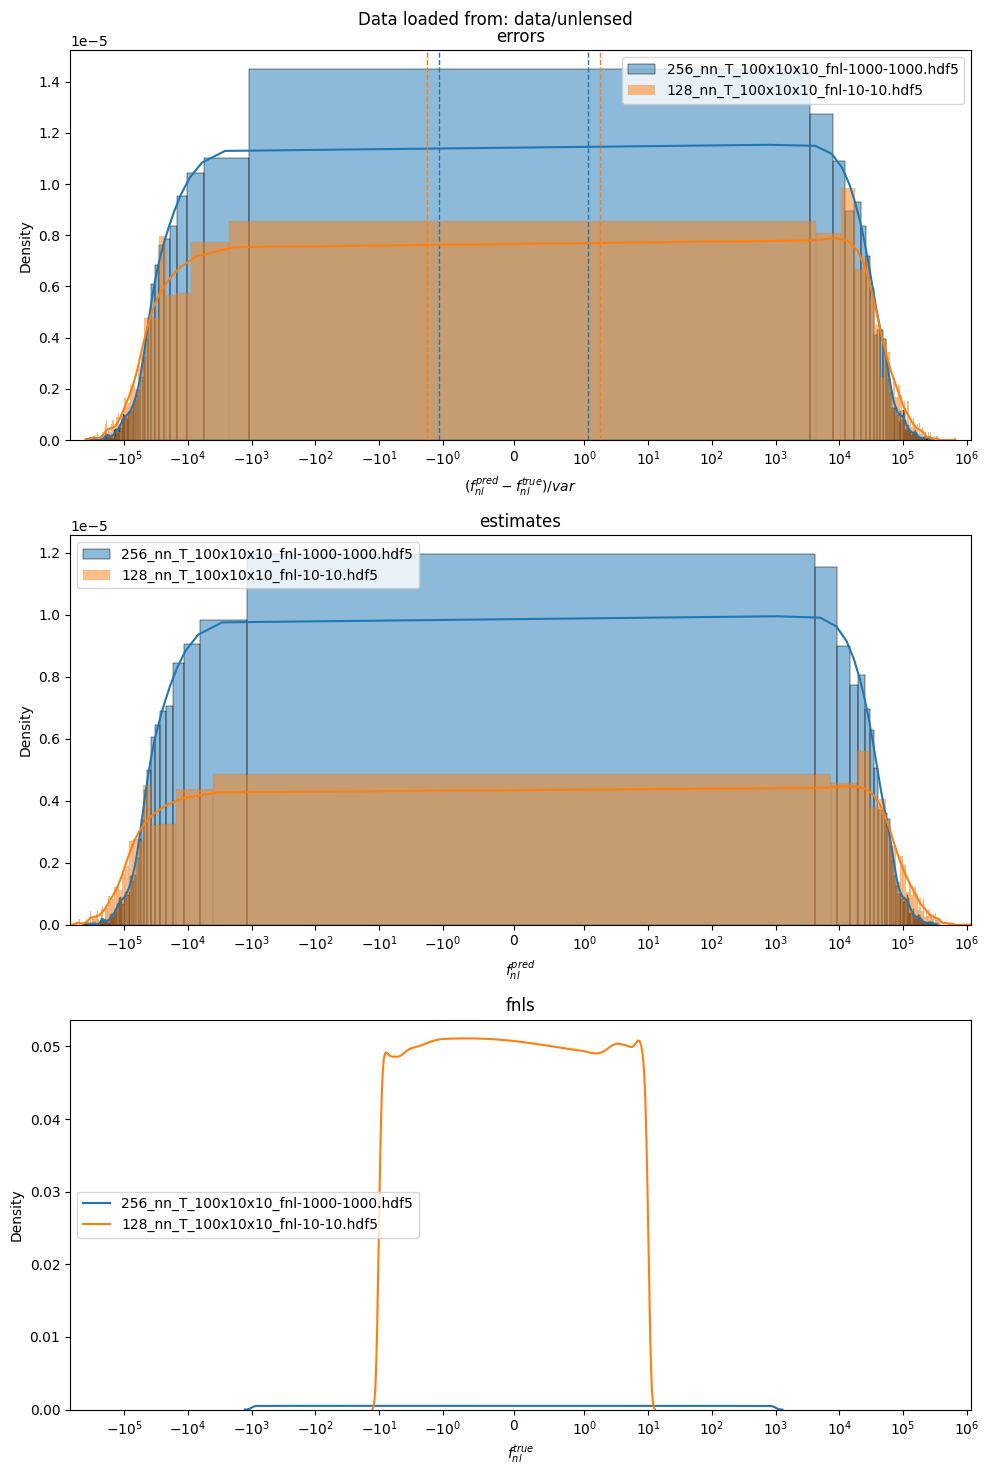

In [10]:
dir_path = 'data/unlensed'
print_dir(dir_path, print_keys=['errors_var', 'fisher', 'fisher_iso'], plot_keys=[
          'errors', 'estimates', 'fnls'])